# Set-up colab


In [1]:
#online for colab environment
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/USA
from fairness_metric_utils import *
from penalty_utils import *

/content/drive/MyDrive/USA


In [3]:
%cd /content/drive/MyDrive/USA/COMPAS

/content/drive/MyDrive/USA/COMPAS


# Load Data

In [ ]:
dataset_path = 'COMPAS/compas-preprocessed-binary.csv'
df=pd.read_csv(dataset_path)

fair_metrics=[ 'FPA', 'EOP', 'FNP', 'FNE'] #'PPE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP' #'GFA', 'PPA', 'FPR', 'PPE', 'FPA', 'OAE', 'EOP', 'FNP', 'FPP'
protected_attributes =['age', 'sex', 'race']
mapping= {
    'age':{
        0: 'age<35',
        1: 'age>35',
    },
    'sex':{
        0: 'fem',
        1: 'mal'
    },
    'race':{
        0: 'African',
        1: 'AsiaWhiHispNatOth'
    }
}
feature_cols= df.columns
target_variable = 'is_violent_recid'
target_variable_labels= ['0','1']
df.head()

,sex,age,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,is_violent_recid
0,1,1,1,0,1,0,0,0,0
1,1,1,1,0,1,0,0,0,0
2,1,0,1,0,5,0,0,0,0
3,1,0,0,0,3,0,0,0,1
4,1,0,0,0,4,0,1,4,0


#Compute Fairness

In [5]:
pairs_dict= {}
fairness_metrics_dict= {}
differences = {}
ratios={}
s= []
for i in range(1,len(protected_attributes)+1):
  pairs_dict[i] = ['-'.join(pair) for pair in combinations(protected_attributes, i)]
#print(pairs_dict)

for i in range(1, len(protected_attributes)+1):
  df=pd.read_csv(dataset_path)
  for sensible_attribute in pairs_dict[i]:
    s = sensible_attribute.split('-')
    print(s)
    if len(s)>1:
      df=pd.read_csv(dataset_path)
      df[sensible_attribute] = reduce(lambda x, y: x.astype(str) + y.astype(str), [df[col] for col in s])
      df = df.drop(columns=s)
    fairness_metrics_dict[sensible_attribute], differences[sensible_attribute], ratios[sensible_attribute] = get_attribute_analysis(df, target_variable, sensible_attribute, fair_metrics, dataset_path, mapping,target_variable_labels)

['age']
FPA {1: 0.044399596367305755, 0: 0.06169212690951821}
Max value: 0.062 (Key: 0)
Min value: 0.044 (Key: 1)
Max-min: 0.018
Max-min: 0.71
EOP {1: 0.8979591836734694, 0: 0.7894736842105263}
Max value: 0.898 (Key: 1)
Min value: 0.789 (Key: 0)
Max-min: 0.109
Max-min: 0.879
FNP {1: 0.04395604395604396, 0: 0.06012024048096192}
Max value: 0.06 (Key: 0)
Min value: 0.044 (Key: 1)
Max-min: 0.016
Max-min: 0.733
FNE {1: 0.8979591836734694, 0: 0.8641975308641975}
Max value: 0.898 (Key: 1)
Min value: 0.864 (Key: 0)
Max-min: 0.034
Max-min: 0.962
['sex']
FPA {1: 0.06014692378328742, 0: 0.03495145631067961}
Max value: 0.06 (Key: 1)
Min value: 0.035 (Key: 0)
Max-min: 0.025
Max-min: 0.583
EOP {1: 0.8213166144200627, 0: 0.8}
Max value: 0.821 (Key: 1)
Min value: 0.8 (Key: 0)
Max-min: 0.021
Max-min: 0.974
FNP {1: 0.05883673927689198, 0: 0.0345489443378119}
Max value: 0.059 (Key: 1)
Min value: 0.035 (Key: 0)
Max-min: 0.024
Max-min: 0.593
FNE {1: 0.8675496688741722, 0: 0.9230769230769231}
Max value: 0.9

In [7]:
def plot_differences(data):
  # Extracting the data
  categories = list(data.keys())
  FPA_values = [data[cat]['FPA'] for cat in categories]
  EOP_values = [data[cat]['EOP'] for cat in categories]
  FNP_values = [data[cat]['FNP'] for cat in categories]
  FNE_values = [data[cat]['FNE'] for cat in categories]

  # Plotting the data
  plt.figure(figsize=(10, 6))

  # Plot each of the four lines
  plt.plot(categories, FPA_values, label='FPA', marker='o')
  plt.plot(categories, EOP_values, label='EOP', marker='o')
  plt.plot(categories, FNP_values, label='FNP', marker='o')
  plt.plot(categories, FNE_values, label='FNE', marker='o')

  # Adding labels to the points
  for i, value in enumerate(FPA_values):
      plt.text(categories[i], value, f'{value:.3f}', ha='center', va='bottom', fontsize=9)

  for i, value in enumerate(EOP_values):
      plt.text(categories[i], value, f'{value:.3f}', ha='center', va='bottom', fontsize=9)

  for i, value in enumerate(FNP_values):
      plt.text(categories[i], value, f'{value:.3f}', ha='center', va='bottom', fontsize=9)

  for i, value in enumerate(FNE_values):
      plt.text(categories[i], value, f'{value:.3f}', ha='center', va='bottom', fontsize=9)

  # Adding labels and title
  plt.xlabel('Categories')
  plt.ylabel('Values')
  plt.title('Line Chart of FPA, EOP, FNP, and FNE by Category')

  # Rotate x-axis labels for readability
  plt.xticks(rotation=45, ha='right')

  # Adding a legend
  plt.legend()

  # Display the plot
  plt.tight_layout()
  plt.show()

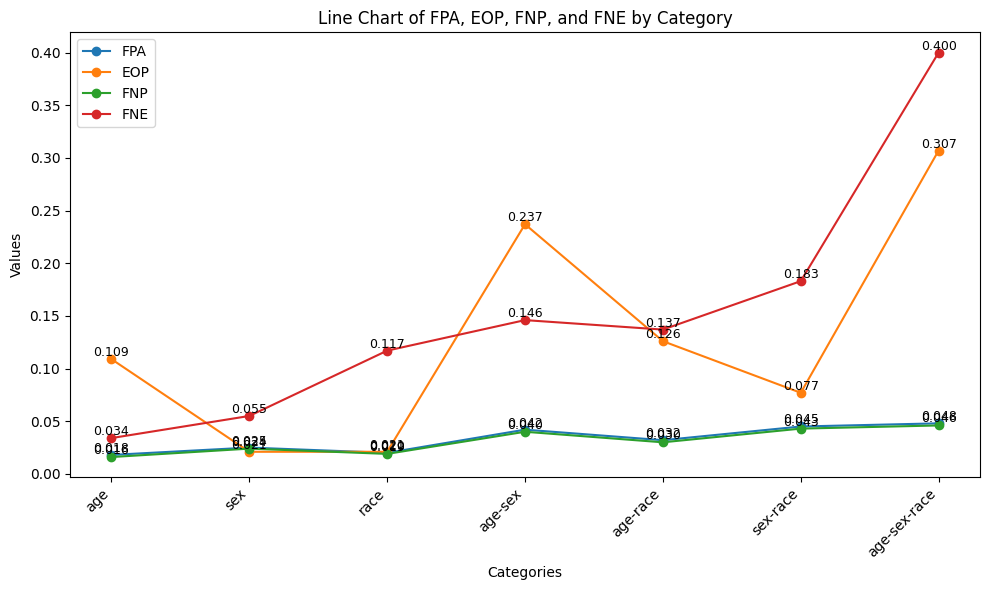

In [8]:
plot_differences(differences)

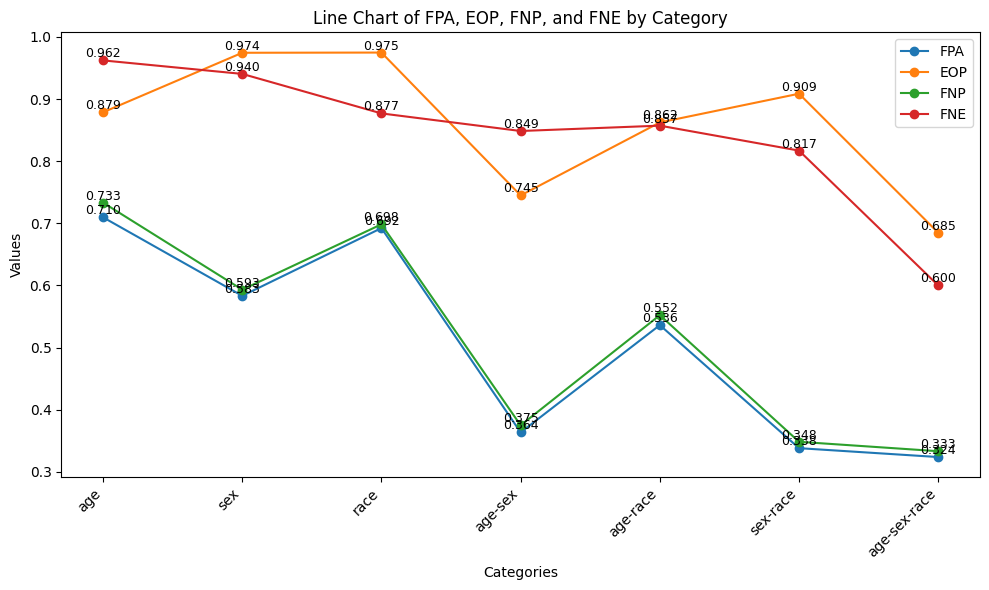

In [9]:
plot_differences(ratios)

# Plot

In [10]:
df=pd.read_csv(dataset_path)

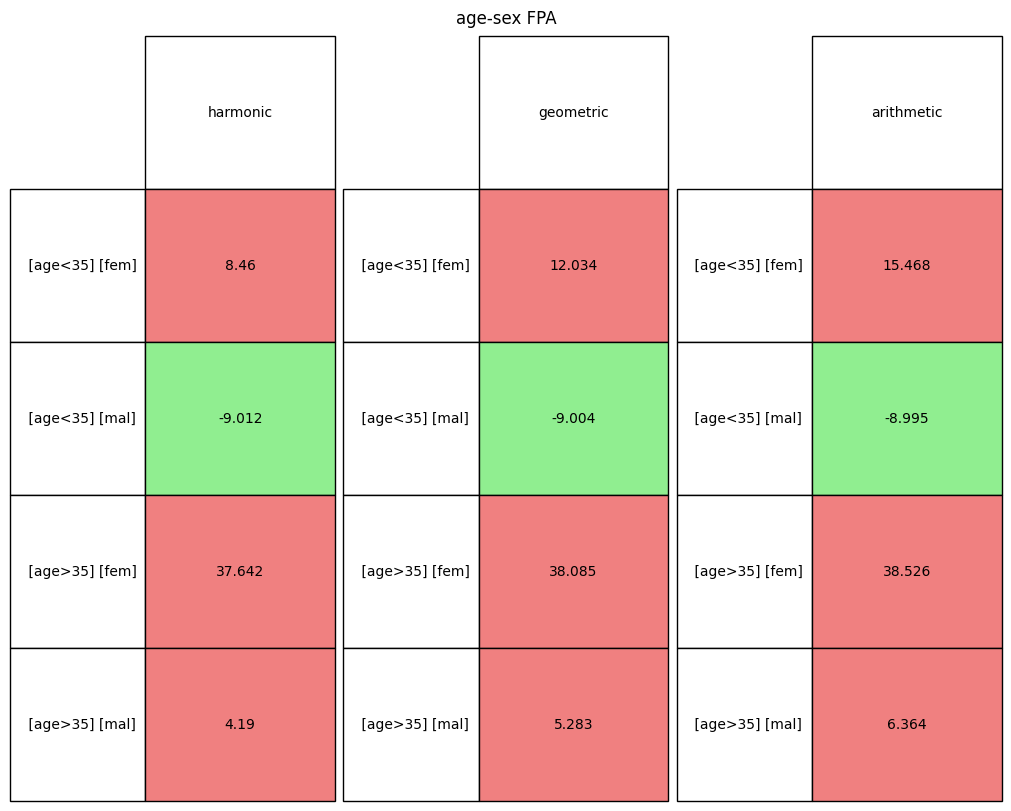

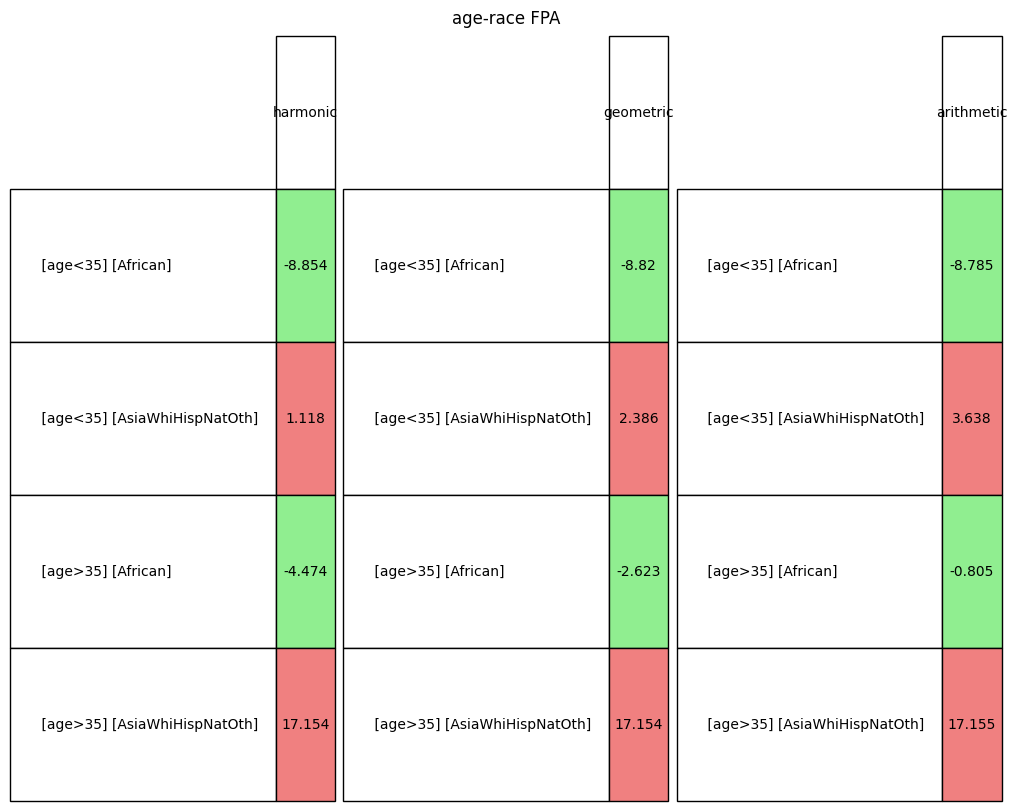

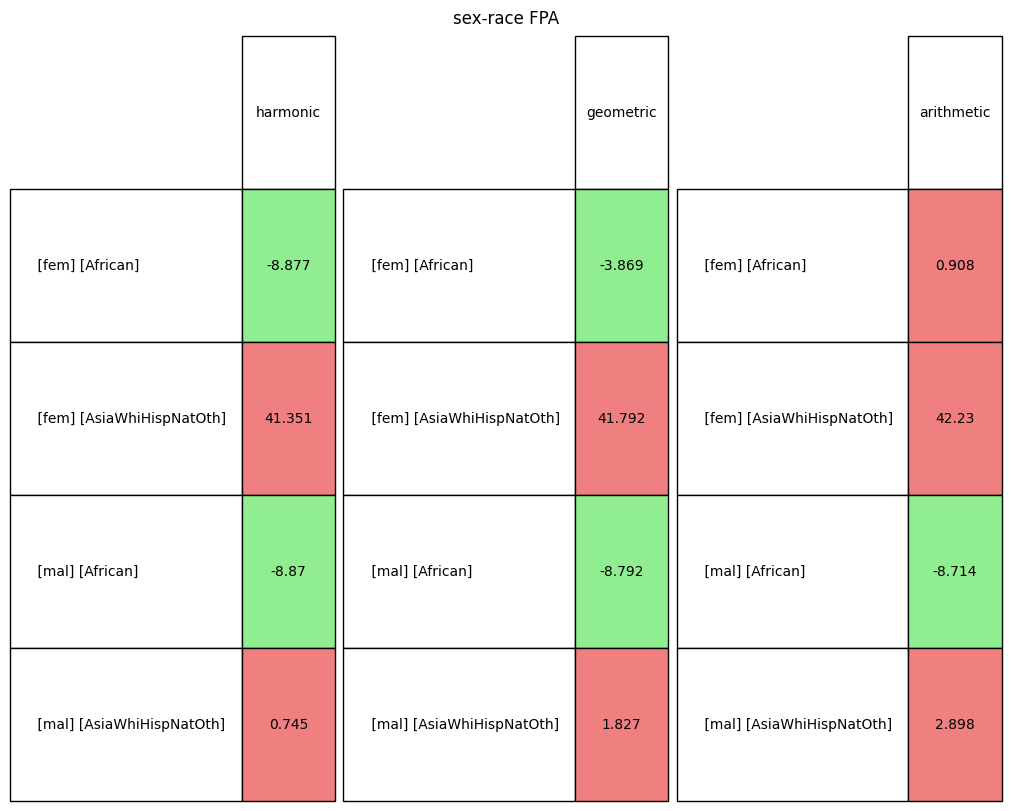

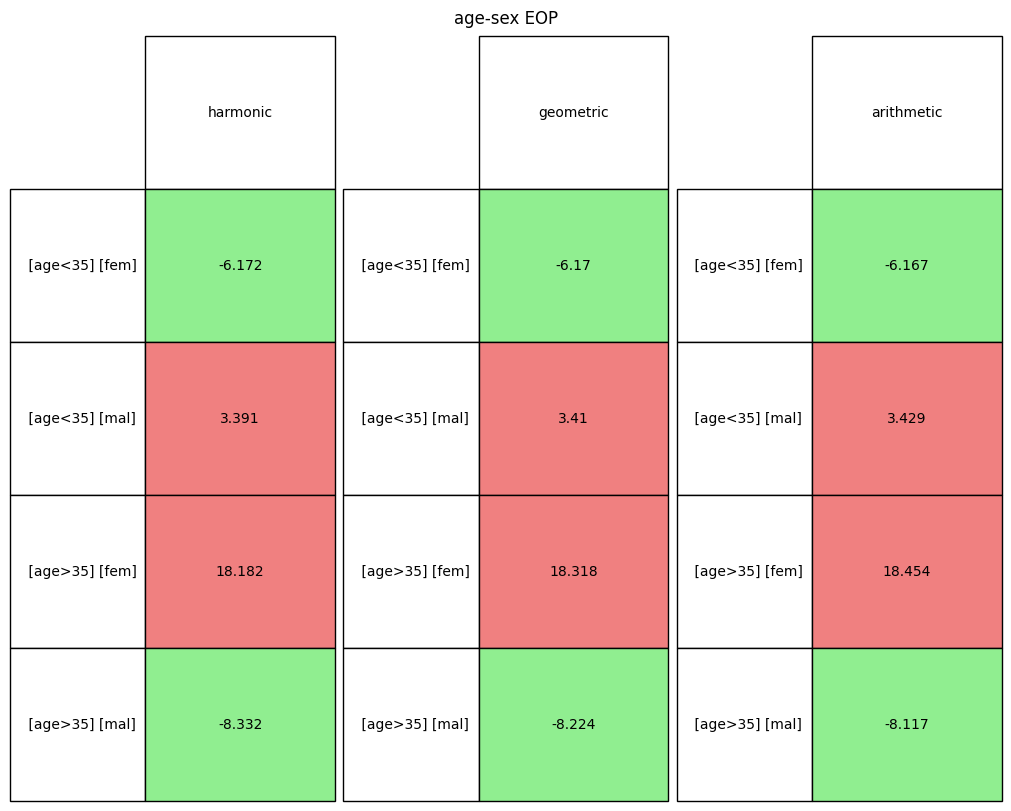

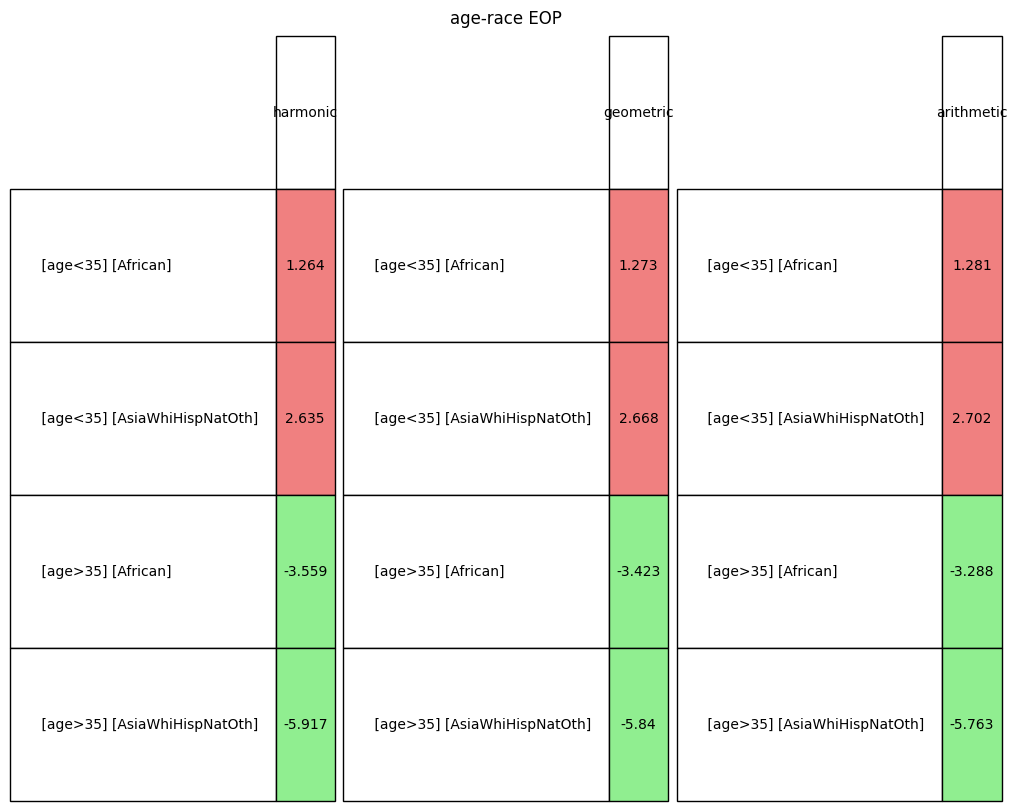

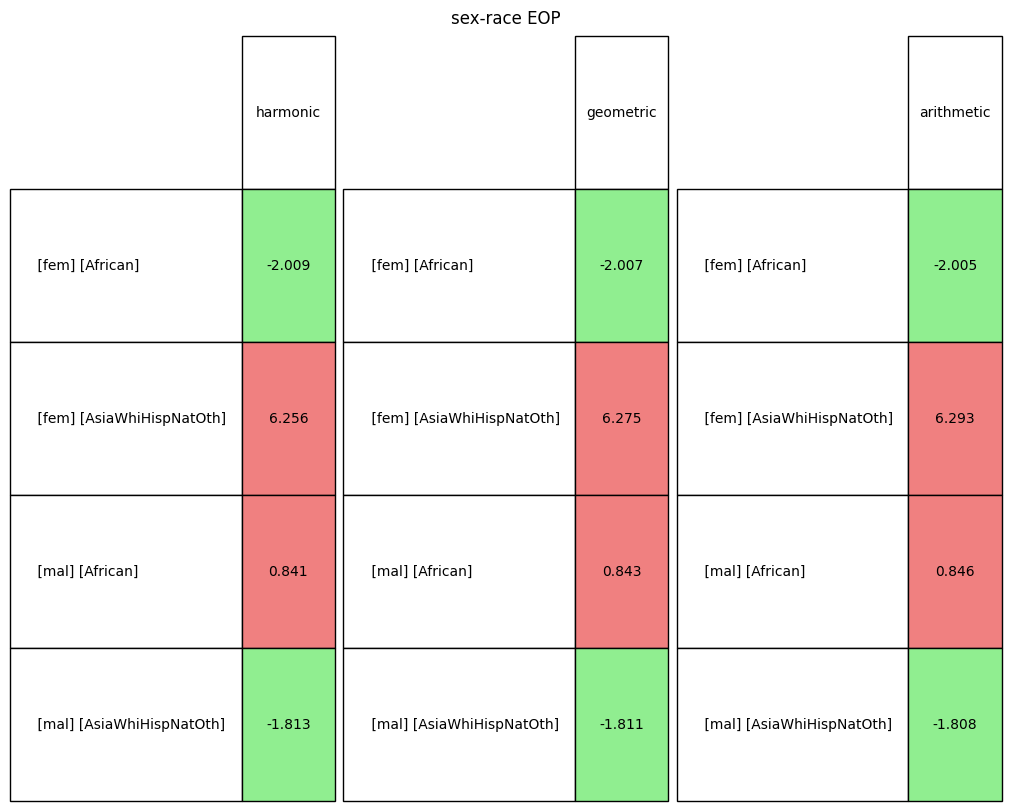

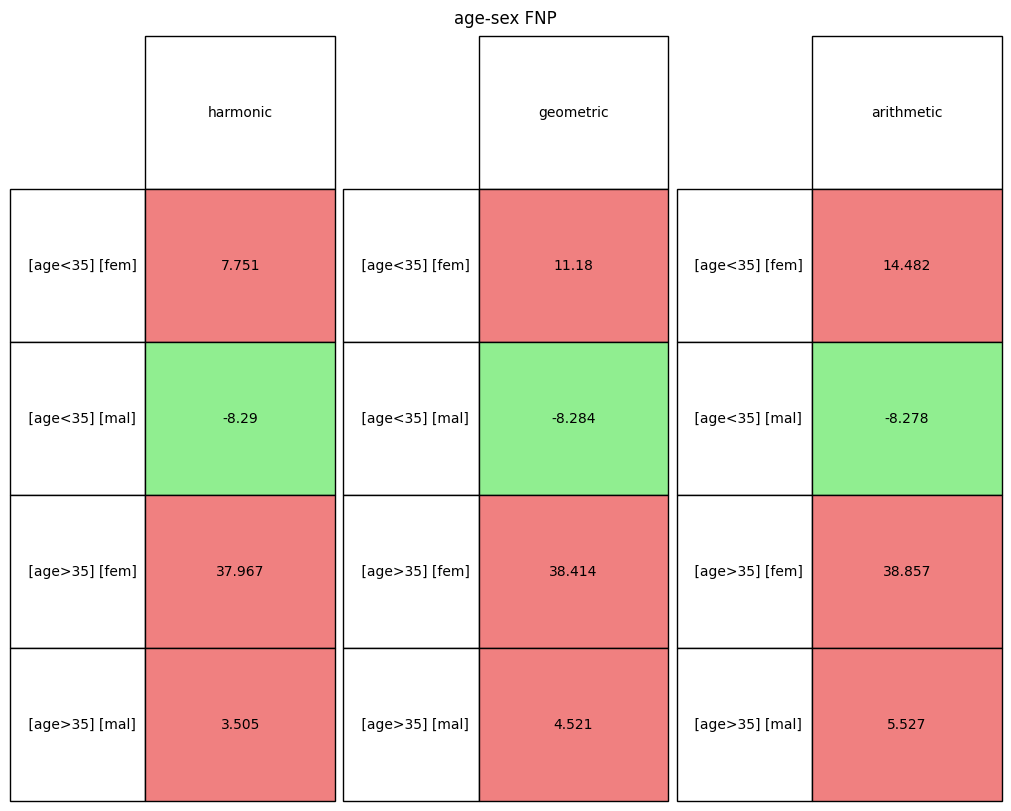

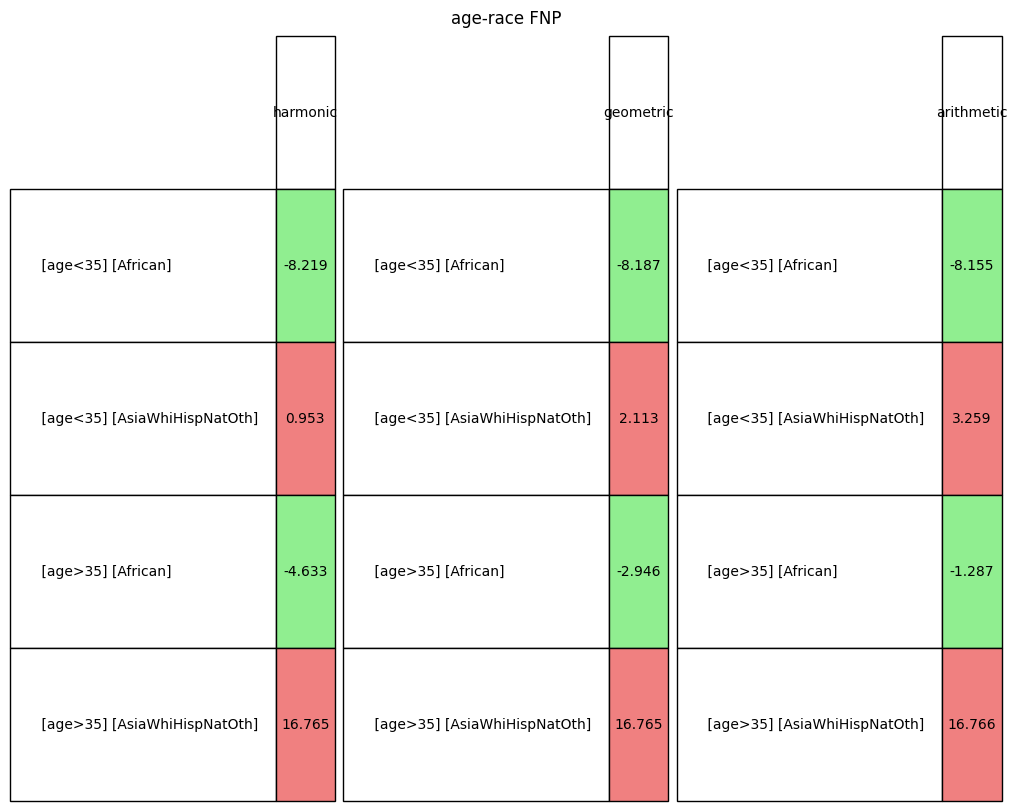

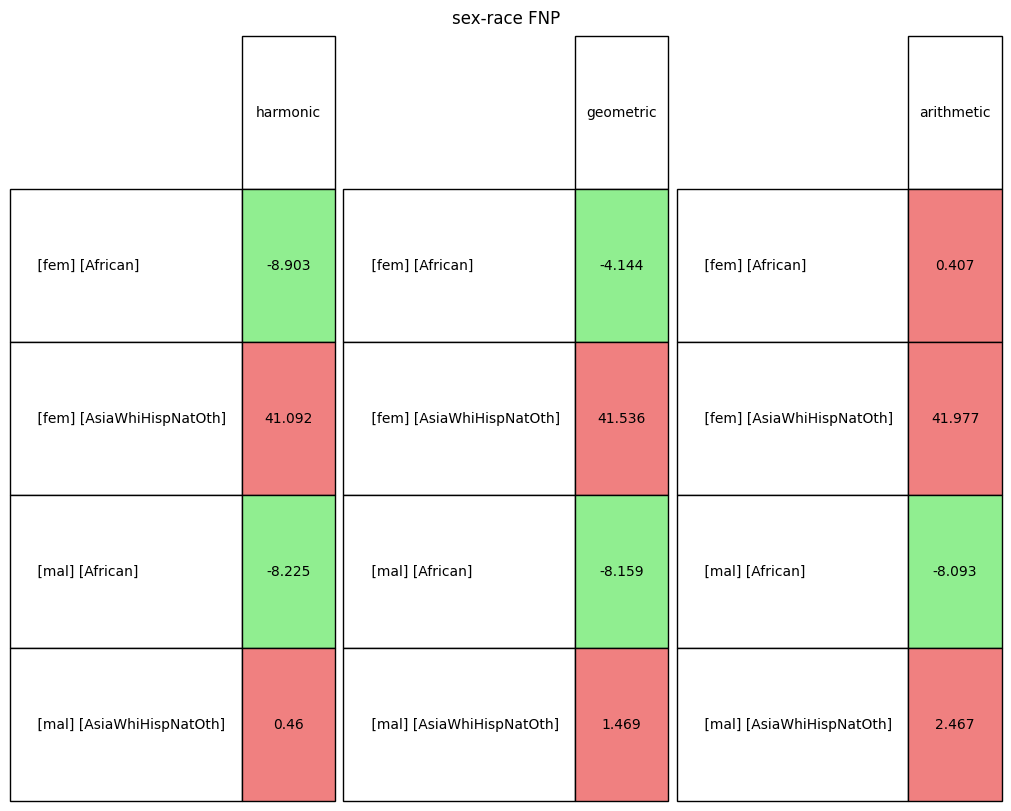

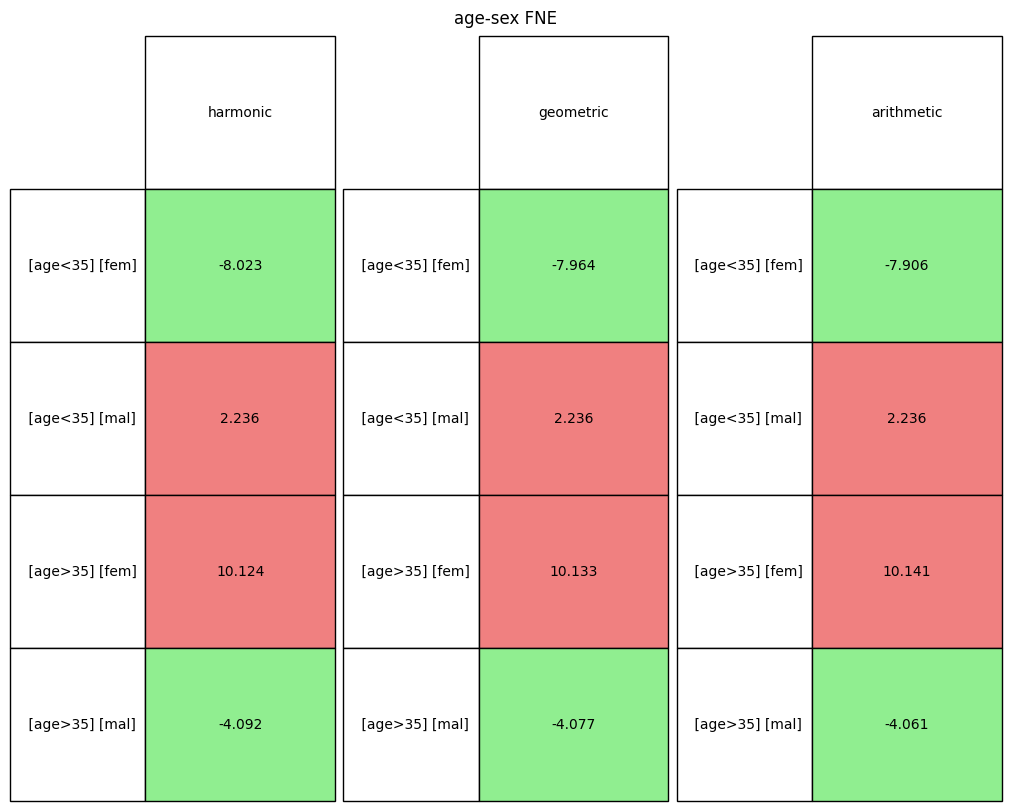

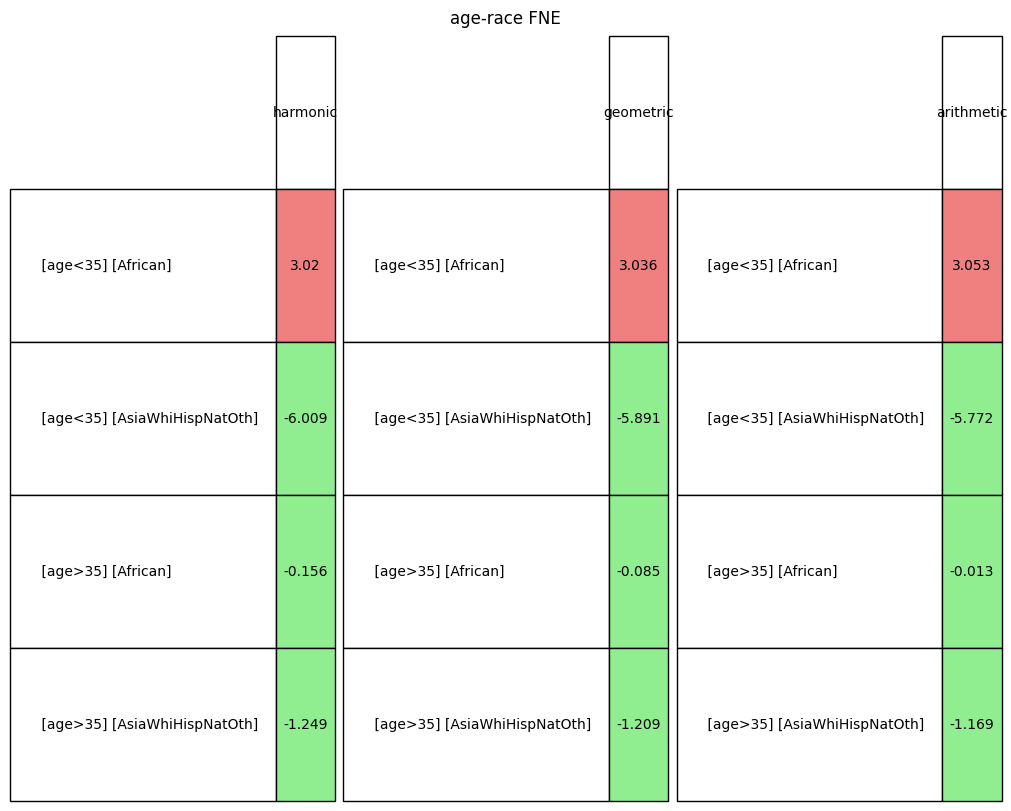

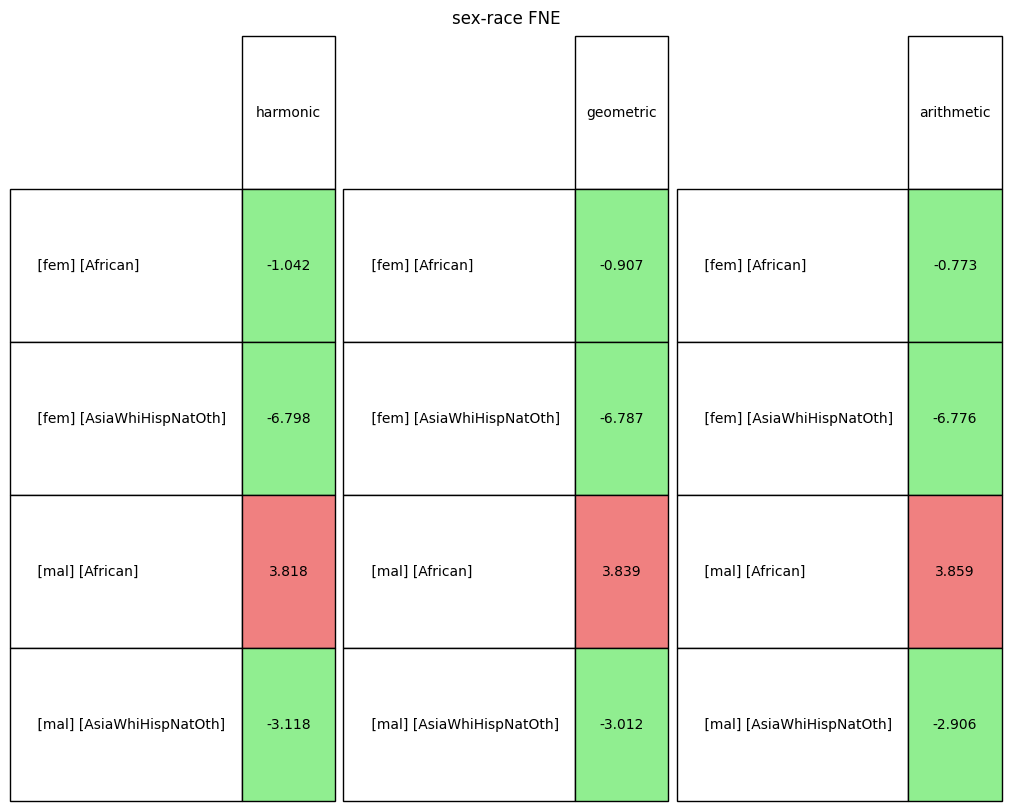

In [11]:
for m in fair_metrics:
  #print(m)
  for i in range(1, len(protected_attributes)+1):
    for sensible_attribute in pairs_dict[i]:
      s = sensible_attribute.split('-')
      #print(sensible_attribute)
      if len(s)==2:
        print_tables_penalty_2(fairness_metrics_dict, df, sensible_attribute, m, mapping, dataset_path)
      #elif len(s)==3:
        #print_tables_penalty_3(fairness_metrics_dict, df, sensible_attribute, m, mapping, dataset_path)
      #elif len(s)==4:
        #print_tables_penalty_4(fairness_metrics_dict, df, sensible_attribute, m, mapping, dataset_path)

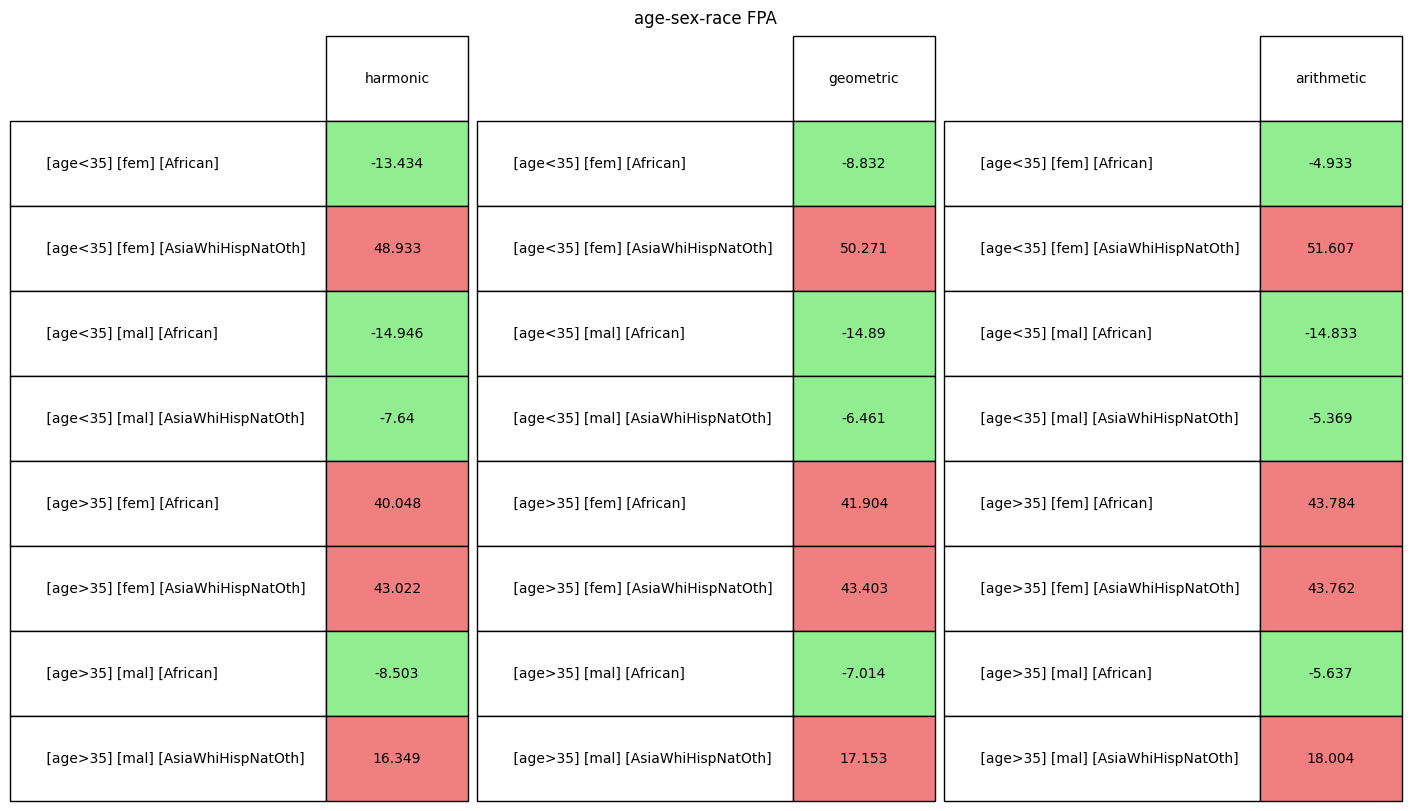

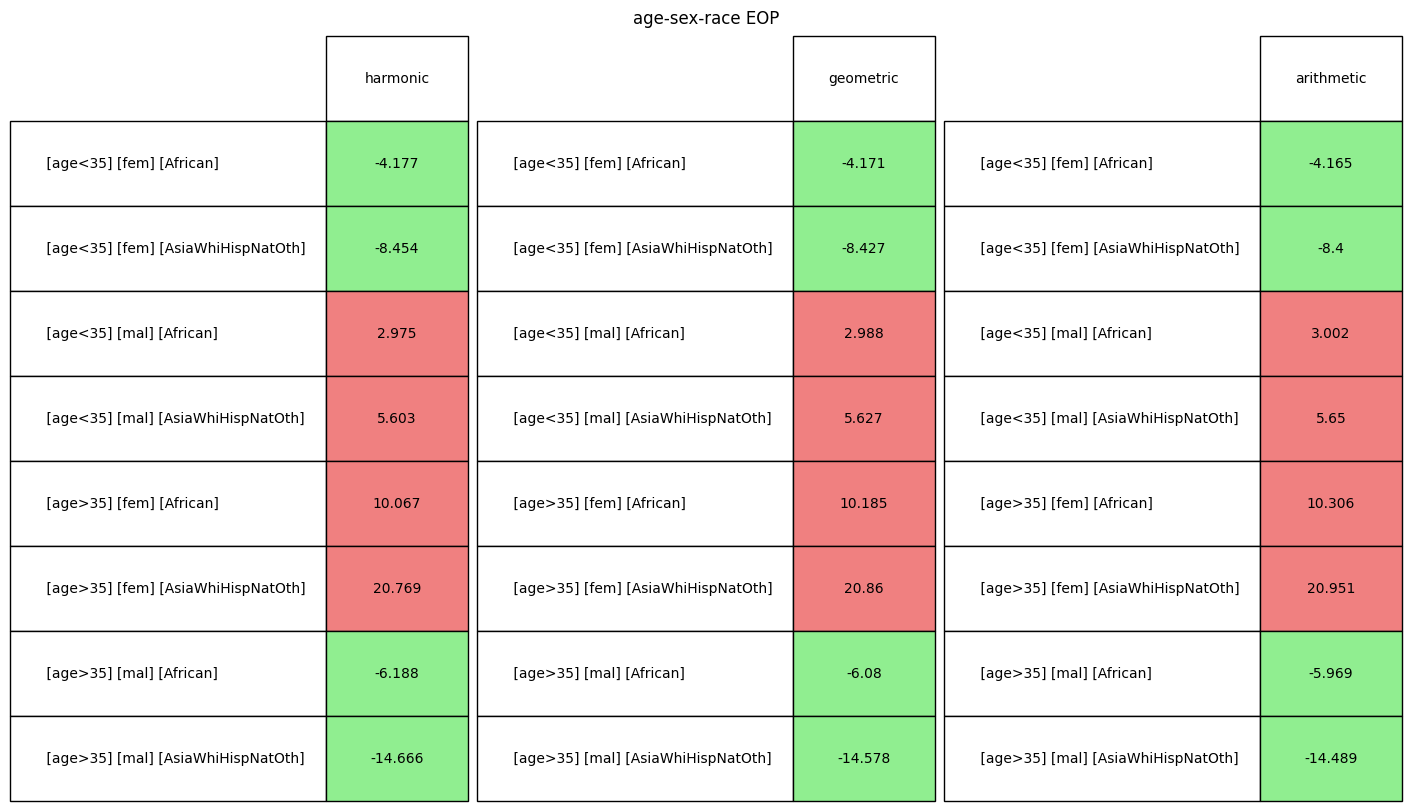

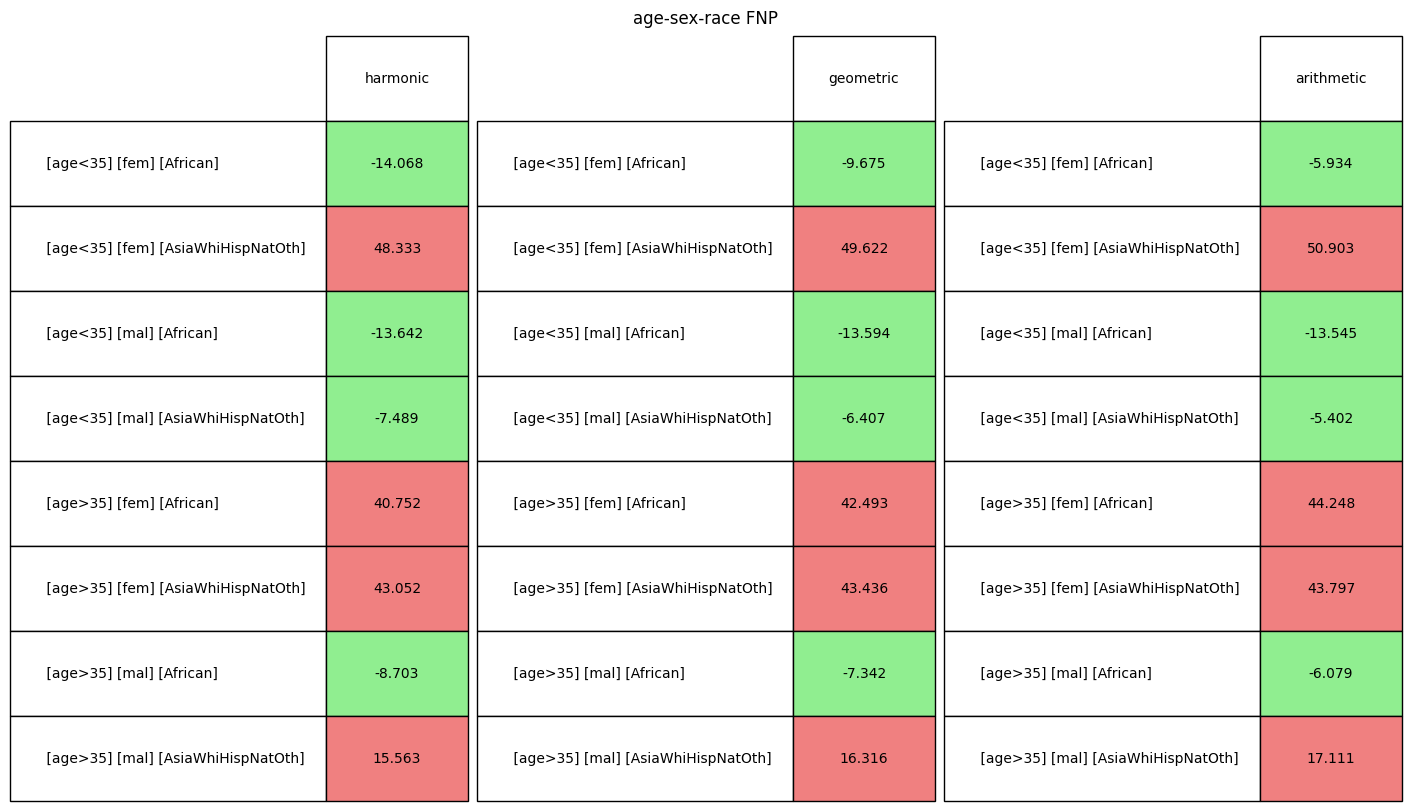

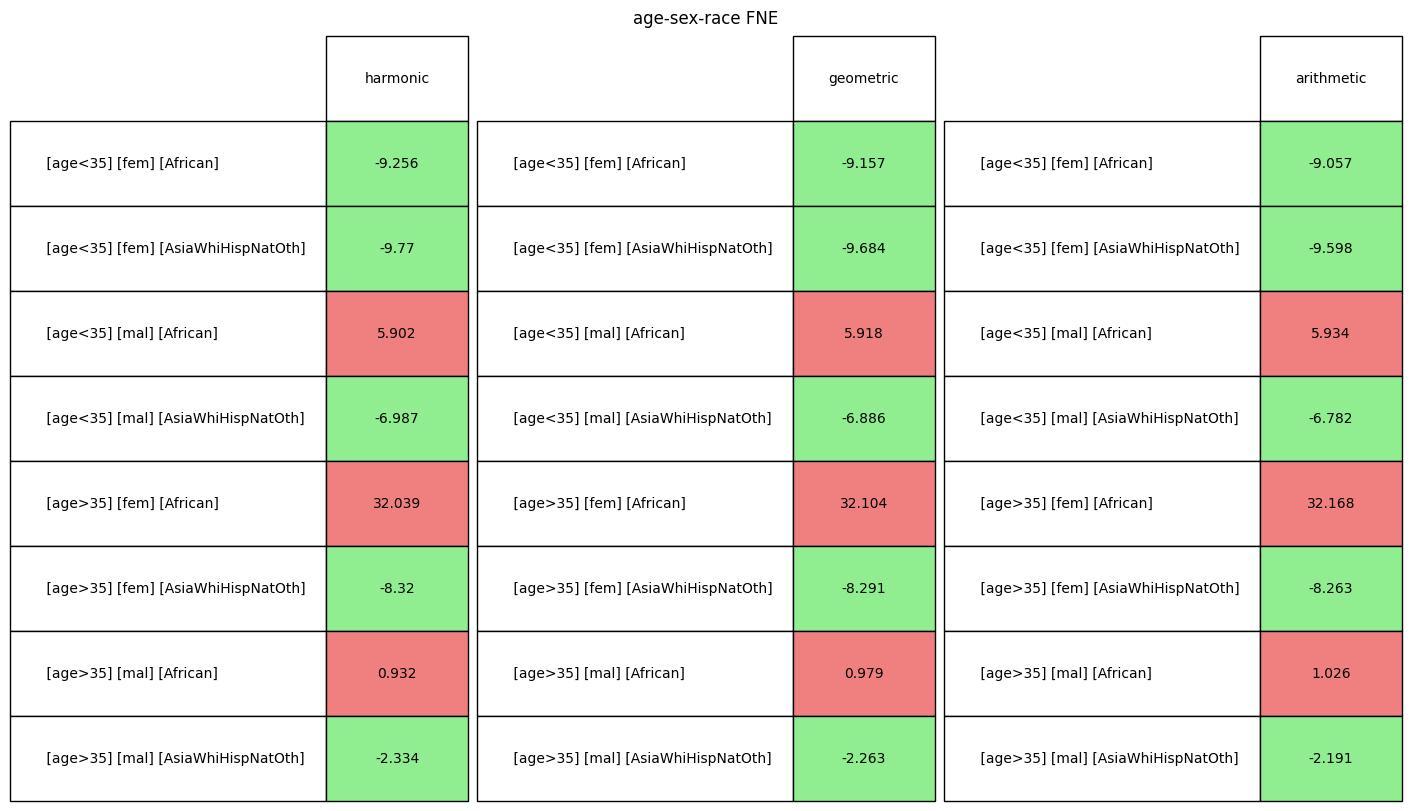

In [12]:
for m in fair_metrics:
  #print(m)
  for i in range(1, len(protected_attributes)+1):
    for sensible_attribute in pairs_dict[i]:
      s = sensible_attribute.split('-')
      #print(sensible_attribute)
      #if len(s)==2:
        #print_tables_penalty_2(fairness_metrics_dict, df, sensible_attribute, m, mapping, dataset_path)
      if len(s)==3:
        print_tables_penalty_3(fairness_metrics_dict, df, sensible_attribute, m, mapping, dataset_path)
      #elif len(s)==4:
        #print_tables_penalty_4(fairness_metrics_dict, df, sensible_attribute, m, mapping, dataset_path)

In [17]:
print('done')

done
